This notebook is for seeing the data collected for imitation learning.

In [14]:
import numpy as np

data = np.load(r"C:\Users\Furkan\Desktop\Kod\Metadrive Autonomous\data\raw\episode_0.npz")

Dosya içeriği: ['rgb', 'depth', 'action']


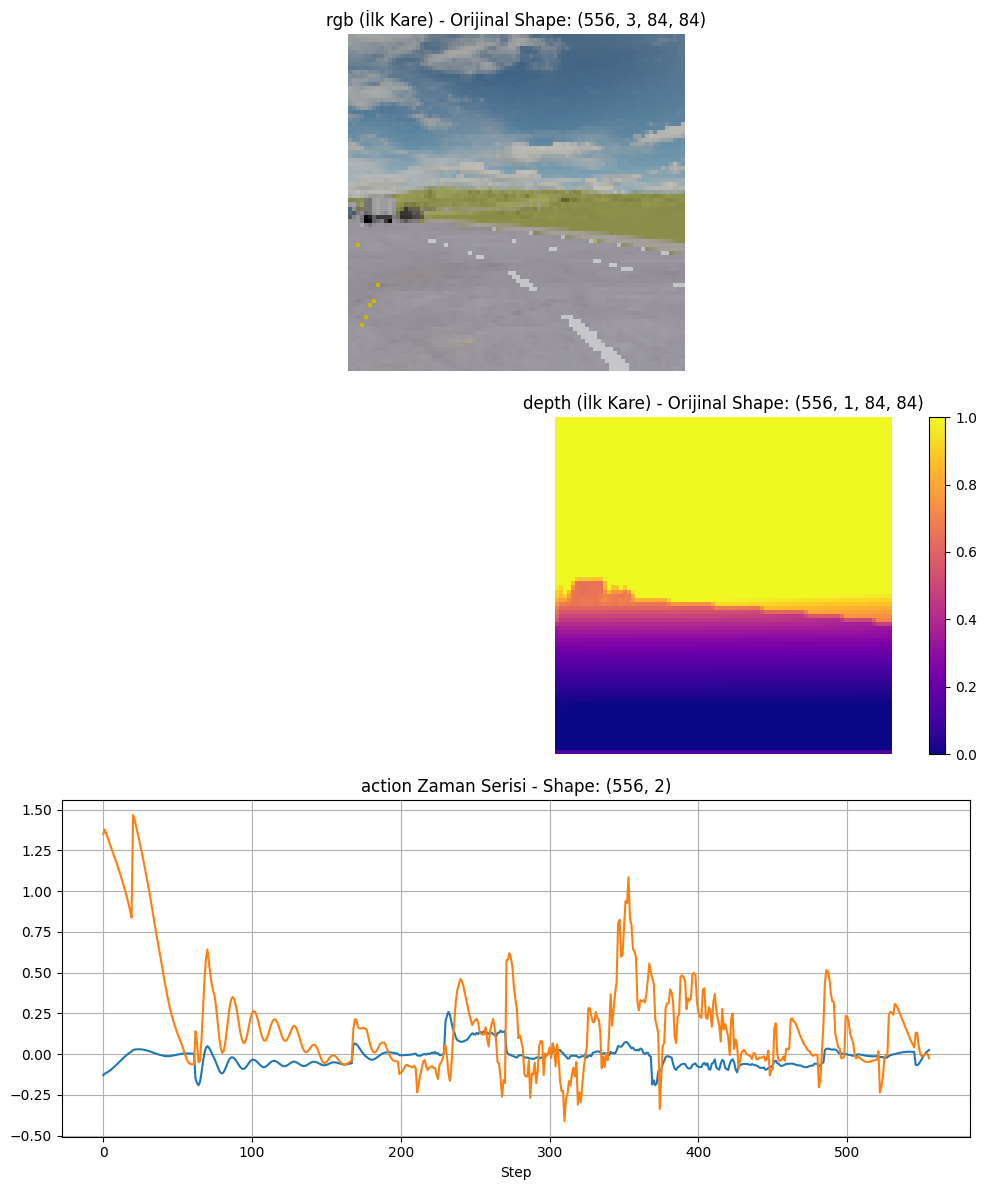

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import os

def visualize_npz(file_path):
    if not os.path.exists(file_path):
        print(f"Hata: {file_path} bulunamadı.")
        return

    data = np.load(file_path)
    keys = list(data.keys())
    print(f"Dosya içeriği: {keys}")

    n_keys = len(keys)
    fig, axes = plt.subplots(n_keys, 1, figsize=(10, 4 * n_keys))
    if n_keys == 1: axes = [axes]

    for i, key in enumerate(keys):
        arr = data[key]
        ax = axes[i]
        
        # 1. Görüntü Verisi Kontrolü
        # Eğer dizi 4 boyutluysa (Step, C, H, W) veya (Step, H, W, C)
        if arr.ndim == 4:
            img = arr[250] # İlk adımı al
            
            # (1, 84, 84) -> (84, 84) yapmak için squeeze kullan
            img = np.squeeze(img)
            
            # Eğer hala 3 boyutluysa ve kanal sayısı baştaysa (C, H, W) -> (H, W, C)
            if img.ndim == 3 and img.shape[0] in [1, 3, 4]:
                img = img.transpose(1, 2, 0)
                if img.shape[-1] == 1: # Tek kanallı ise tekrar squeeze
                    img = img.squeeze(-1)

            # --- DERİNLİK (DEPTH) İÇİN ÖZEL GÖRSELLEŞTİRME ---
            if 'depth' in key.lower():
                # Z-buffer verisinde kontrastı artırmak için Min-Max ölçeklendirme
                img_min, img_max = np.min(img), np.max(img)
                if img_max > img_min: # Sıfıra bölme hatasını engelle
                    img_normalized = (img - img_min) / (img_max - img_min)
                else:
                    img_normalized = img
                
                # Derinlik için 'plasma' renk haritası kullanıyoruz (yakın yerler koyu, uzak yerler açık)
                im = ax.imshow(img_normalized, cmap='plasma')
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04) # Renk çubuğu ekle
            
            # --- RGB İÇİN ÖZEL GÖRSELLEŞTİRME ---
            elif 'rgb' in key.lower():
                # Eğer float ise ve değerler 0-255 arasındaysa (1.0'dan büyükse), uint8'e çevir
                # (matplotlib float tipindeki resimlerin 0-1 arasında olmasını bekler)
                if img.max() > 1.0:
                    img = img.astype(np.uint8)
                ax.imshow(img)
                
            # --- DİĞER GÖRÜNTÜLER ---
            else:
                ax.imshow(img, cmap='gray' if img.ndim == 2 else None)

            ax.set_title(f"{key} (İlk Kare) - Orijinal Shape: {arr.shape}")
            ax.axis('off')
            
        # 2. Zaman Serisi Verisi (Action, Reward vb.)
        elif arr.ndim <= 2:
            ax.plot(arr)
            ax.set_title(f"{key} Zaman Serisi - Shape: {arr.shape}")
            ax.set_xlabel("Step")
            ax.grid(True)
            
        else:
            ax.text(0.5, 0.5, f"{key}: Desteklenmeyen boyut {arr.shape}", 
                    ha='center', va='center')
            ax.set_title(key)

    plt.tight_layout()
    plt.show()

# Kullanım:
visualize_npz(r"C:\Users\Furkan\Desktop\Kod\Metadrive Autonomous\data\raw\episode_0.npz")

In [3]:
keys = list(data.keys())
print(f"Dosya içeriği: {keys}")

Dosya içeriği: ['rgb', 'depth', 'action']


In [21]:
data.get("action")[0]

array([-0.12874566,  1.3514872 ], dtype=float32)